# Part A: Conceptual Foundation (Theory)

**Q1. What are Ensemble Learning Methods and why are they effective?**



Ensemble Learning combines predictions from multiple machine learning models to produce a better final prediction. Instead of relying on a single model, it aggregates the strengths of several models, resulting in higher accuracy, improved stability, and better generalization. It also helps reduce overfitting and prediction errors.

**Q2. Explain the difference between Bagging, Boosting, and Voting.**

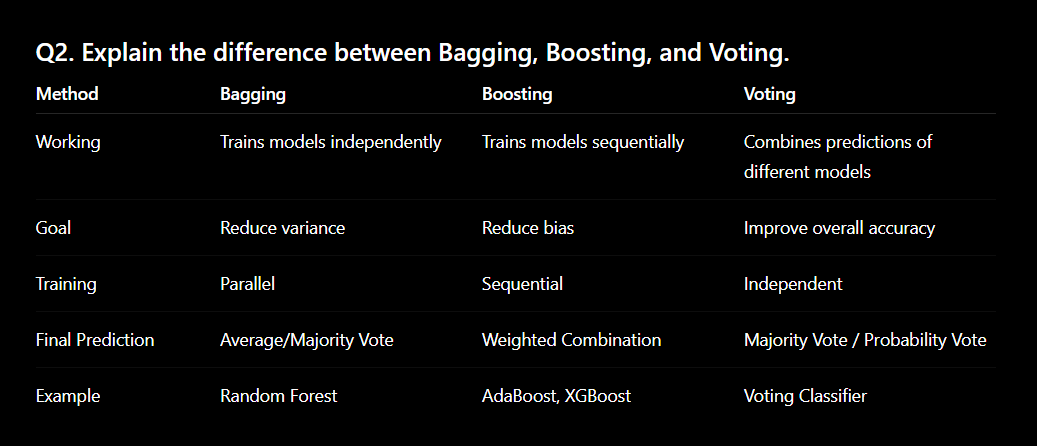

In [5]:
from IPython.display import Image, display

display(Image(filename='ensemble.png', width=1000))

A comparison table makes it easier to understand the differences between Bagging, Boosting, and Voting at a glance.

**Q3. What is Bias–Variance Trade-off, and how do ensemble methods address it?**

Answer

The Bias–Variance Trade-off describes the balance between underfitting (high bias) and overfitting (high variance). High bias models are too simple, while high variance models memorize training data. Ensemble methods reduce variance using Bagging and reduce bias using Boosting, resulting in better model performance.

**Q4. Explain Voting Classifier and Stacking Ensemble.**

Answer

A Voting Classifier combines predictions from multiple classifiers and selects the final prediction using majority voting (Hard Voting) or average probabilities (Soft Voting). Stacking Ensemble trains multiple base models and then uses a meta-model to learn from their predictions, often achieving better performance than individual models.

**Q5. Compare AdaBoost, Gradient Boosting, LightGBM, and XGBoost conceptually.**

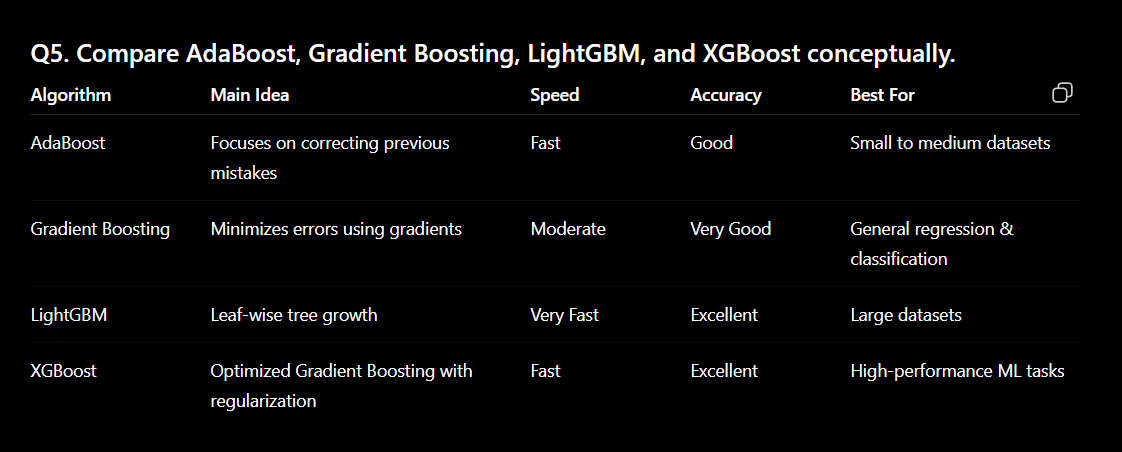

In [6]:

display(Image(filename='boosts.png', width=1000))

The table provides a concise conceptual comparison of popular boosting algorithms, making it easier to identify their strengths and typical use cases.

#  Conclusion

**In this section, the fundamental concepts of Ensemble Learning were studied, including Bagging, Boosting, Voting, Bias–Variance Trade-off, Voting Classifier, Stacking Ensemble, AdaBoost, Gradient Boosting, LightGBM, and XGBoost. These concepts explain how combining multiple machine learning models improves prediction accuracy, reduces overfitting, and enhances model stability. This theoretical understanding provides the foundation for implementing ensemble learning techniques in the practical sections of this project.**

#  Part B: Dataset Understanding & Preparation

## Step 1: Import Required Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### Explanation

The required libraries are imported for data handling, preprocessing, feature scaling, and train-test splitting.

## Step 2: Load Dataset

In [8]:
df = pd.read_csv("/content/Smart_Outcome_Predictor_Dataset_5200 - Smart_Outcome_Predictor_Dataset_5200.csv.csv")

In [9]:
df.head()

,student_id,age,country_region,device_type,education_background,course_level,course_category,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,700001,32,Europe,Laptop,Undergrad,Intermediate,Business,2024-03-18,12,1,7.6,1,6,1,1,53.3,0.655,0,49.8
1,700002,17,Europe,Laptop,Undergrad,Intermediate,Programming,2024-08-22,34,16,27.2,6,4,7,1,51.5,1.000,1,84.0
2,700003,25,Europe,Mobile,Graduate,Advanced,Programming,2024-09-28,39,6,7.1,16,2,2,0,62.2,0.810,0,62.5
3,700004,26,Asia,Mobile,Undergrad,Beginner,Design,2024-03-09,10,34,22.1,57,9,6,0,59.3,0.875,1,89.5
4,700005,26,Asia,Tablet,WorkingPro,Advanced,Business,2024-03-21,12,22,32.3,41,9,2,0,65.1,0.814,0,67.4


### Explanation

The dataset is loaded into a pandas DataFrame for further preprocessing and analysis.

## Step 3: Identify Features and Target Variables

### Objective

In this step, we identify the input features and target variables required for both the classification and regression tasks. The same feature set will be used for both models, while the target variable will differ based on the prediction objective.

In [13]:
# Input Features
X = df.drop(["completion_status", "final_score"], axis=1)

# Target Variable for Classification
y_classification = df["completion_status"]

# Target Variable for Regression
y_regression = df["final_score"]

print("Features Shape:", X.shape)
print("Classification Target Shape:", y_classification.shape)
print("Regression Target Shape:", y_regression.shape)

Features Shape: (5200, 17)
Classification Target Shape: (5200,)
Regression Target Shape: (5200,)


### Interpretation

The dataset has been successfully divided into input features and target variables. The **completion_status** column will be used for the classification task, while the **final_score** column will be used for the regression task. All remaining columns are considered input features for training the ensemble learning models.

## Step 4: Perform Train-Test Split

### Objective

In this step, the dataset is divided into training and testing sets for both classification and regression tasks. The training dataset is used to train the model, while the testing dataset is used to evaluate its performance.

In [14]:
from sklearn.model_selection import train_test_split

# Classification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_classification,
    test_size=0.2,
    random_state=42,
    stratify=y_classification
)

# Regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_regression,
    test_size=0.2,
    random_state=42
)

print("Classification Train Shape:", X_train.shape)
print("Classification Test Shape :", X_test.shape)

print("Regression Train Shape:", X_train_reg.shape)
print("Regression Test Shape :", X_test_reg.shape)

Classification Train Shape: (4160, 17)
Classification Test Shape : (1040, 17)
Regression Train Shape: (4160, 17)
Regression Test Shape : (1040, 17)


### Interpretation

The dataset has been successfully divided into training and testing sets using an 80:20 ratio. The classification task uses stratified sampling to preserve class distribution, while the regression task uses a standard random split.

## Step 5: Apply Encoding

### Objective

In this step, categorical features are converted into numerical values using encoding techniques so that machine learning models can process the dataset.

In [15]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

X_train_reg = pd.get_dummies(X_train_reg, drop_first=True)
X_test_reg = pd.get_dummies(X_test_reg, drop_first=True)

X_train_reg, X_test_reg = X_train_reg.align(
    X_test_reg,
    join="left",
    axis=1,
    fill_value=0
)

### Interpretation

All categorical variables have been converted into numerical features using One-Hot Encoding, making the dataset suitable for machine learning models.

## Step 6: Apply Feature Scaling

### Objective

In this step, numerical features are standardized using StandardScaler to improve model performance.

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

scaler_reg = StandardScaler()

X_train_reg = scaler_reg.fit_transform(X_train_reg)
X_test_reg = scaler_reg.transform(X_test_reg)

print("Feature Scaling Completed Successfully!")

Feature Scaling Completed Successfully!


### Interpretation

The numerical features have been standardized using StandardScaler. The dataset is now ready for training ensemble learning models.

## Step 7: Verify the Prepared Dataset

### Objective

In this step, we verify the dimensions of the processed training and testing datasets before building the machine learning models.

In [17]:
print("Classification Training Shape :", X_train.shape)
print("Classification Testing Shape :", X_test.shape)

print("Regression Training Shape :", X_train_reg.shape)
print("Regression Testing Shape :", X_test_reg.shape)

Classification Training Shape : (4160, 390)
Classification Testing Shape : (1040, 390)
Regression Training Shape : (4160, 390)
Regression Testing Shape : (1040, 390)


### Interpretation

The processed datasets have been successfully verified. The training and testing datasets are now ready for implementing ensemble learning algorithms.

#  Conclusion

**The dataset has been successfully prepared for both classification and regression tasks. The data was split into training and testing sets, categorical features were encoded, numerical features were scaled, and the processed datasets were verified. The dataset is now ready for implementing ensemble learning models in the next part.**

# Part C: Bagging (Bootstrap Aggregating)

## Step 1: Implement Bagging Classifier

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report

bagging_classifier = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)

bagging_classifier.fit(X_train, y_train)

y_pred = bagging_classifier.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.7230769230769231

Classification Report

              precision    recall  f1-score   support

           0       0.76      0.82      0.79       650
           1       0.65      0.56      0.60       390

    accuracy                           0.72      1040
   macro avg       0.70      0.69      0.69      1040
weighted avg       0.72      0.72      0.72      1040



### Interpretation

The Bagging Classifier trains multiple Decision Tree models on different bootstrap samples and combines their predictions using majority voting. This improves classification performance and reduces overfitting.

## Step 2: Implement Bagging Regressor

In [19]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

bagging_regressor = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=100,
    random_state=42
)

bagging_regressor.fit(X_train_reg, y_train_reg)

y_pred_reg = bagging_regressor.predict(X_test_reg)

print("MAE :", mean_absolute_error(y_test_reg, y_pred_reg))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)))
print("R² Score:", r2_score(y_test_reg, y_pred_reg))

MAE : 7.954920192307691
RMSE: 9.9909146098516
R² Score: 0.46575354366731225


### Interpretation

The Bagging Regressor combines the predictions of multiple Decision Tree Regressors by averaging their outputs. This reduces prediction errors and improves the overall regression performance.

## Step 3: Compare Bagging Results with a Single Base Model

In [20]:
# Single Decision Tree Classifier
single_classifier = DecisionTreeClassifier(random_state=42)

single_classifier.fit(X_train, y_train)

single_pred = single_classifier.predict(X_test)

print("Single Decision Tree Accuracy:",
      accuracy_score(y_test, single_pred))

print("Bagging Classifier Accuracy:",
      accuracy_score(y_test, y_pred))

Single Decision Tree Accuracy: 0.6509615384615385
Bagging Classifier Accuracy: 0.7230769230769231


### Interpretation

The comparison shows the difference between a single Decision Tree and the Bagging Classifier. In most cases, the Bagging model achieves better accuracy because it combines multiple models, reducing variance and improving prediction stability.

#  Conclusion

**In this section, Bagging techniques were successfully implemented for both classification and regression tasks. The Bagging Classifier improved course completion prediction, while the Bagging Regressor enhanced final score prediction. Comparing the Bagging model with a single Decision Tree demonstrated that ensemble learning generally provides better accuracy, stability, and generalization.**

#  Part D: Boosting Algorithms


## Step 1: Implement AdaBoost Classifier

In [22]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer

# Initialize SimpleImputer for numerical data (mean imputation is a common choice)
imputer = SimpleImputer(strategy='mean')

# Fit and transform the training data
X_train_imputed = imputer.fit_transform(X_train)
# Transform the test data using the fitted imputer
X_test_imputed = imputer.transform(X_test)

ada_classifier = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

# Fit the classifier using the imputed data
ada_classifier.fit(X_train_imputed, y_train)

# Make predictions using the imputed test data
y_pred = ada_classifier.predict(X_test_imputed)

print("Accuracy Score :", accuracy_score(y_test, y_pred))
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy Score : 0.7259615384615384

Classification Report

              precision    recall  f1-score   support

           0       0.75      0.83      0.79       650
           1       0.66      0.55      0.60       390

    accuracy                           0.73      1040
   macro avg       0.71      0.69      0.70      1040
weighted avg       0.72      0.73      0.72      1040



### Interpretation

The AdaBoost Classifier builds multiple weak learners sequentially. Each new learner focuses on correcting the mistakes made by the previous learners, resulting in improved classification performance.

## Step 2: Implement AdaBoost Regressor

In [24]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.impute import SimpleImputer

# Initialize SimpleImputer for numerical data (mean imputation is a common choice)
imputer_reg = SimpleImputer(strategy='mean')

# Fit and transform the training data for regression
X_train_reg_imputed = imputer_reg.fit_transform(X_train_reg)
# Transform the test data using the fitted imputer
X_test_reg_imputed = imputer_reg.transform(X_test_reg)

ada_regressor = AdaBoostRegressor(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

# Fit the regressor using the imputed data
ada_regressor.fit(X_train_reg_imputed, y_train_reg)

# Make predictions using the imputed test data
y_pred_reg = ada_regressor.predict(X_test_reg_imputed)

print("MAE :", mean_absolute_error(y_test_reg, y_pred_reg))
print("RMSE :", np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)))
print("R² Score :", r2_score(y_test_reg, y_pred_reg))

MAE : 8.617202778058477
RMSE : 10.579956884202627
R² Score : 0.4009005077334131


### Interpretation

The AdaBoost Regressor improves prediction accuracy by sequentially training weak regression models. Each model attempts to reduce the errors made by the previous model, leading to better regression performance.

## Step 4: Implement Gradient Boosting Classifier

In [26]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

gb_classifier = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# Fit the classifier using the imputed data from the AdaBoost step
gb_classifier.fit(X_train_imputed, y_train)

# Make predictions using the imputed test data
y_pred_gb = gb_classifier.predict(X_test_imputed)

print("Accuracy Score :", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report\n")
print(classification_report(y_test, y_pred_gb))

Accuracy Score : 0.7288461538461538

Classification Report

              precision    recall  f1-score   support

           0       0.76      0.83      0.79       650
           1       0.67      0.55      0.61       390

    accuracy                           0.73      1040
   macro avg       0.71      0.69      0.70      1040
weighted avg       0.72      0.73      0.72      1040



### Interpretation

The Gradient Boosting Classifier trains decision trees sequentially, where each new tree corrects the errors of the previous trees. This process improves classification accuracy and reduces prediction errors.

## Step 5: Implement Gradient Boosting Regressor

In [28]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

gb_regressor = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_regressor.fit(X_train_reg_imputed, y_train_reg)

y_pred_gb_reg = gb_regressor.predict(X_test_reg_imputed)

print("MAE :", mean_absolute_error(y_test_reg, y_pred_gb_reg))
print("RMSE :", np.sqrt(mean_squared_error(y_test_reg, y_pred_gb_reg)))
print("R² Score :", r2_score(y_test_reg, y_pred_gb_reg))

MAE : 7.858502306779104
RMSE : 9.83753638496968
R² Score : 0.4820308917706435


### Interpretation

The Gradient Boosting Regressor improves prediction accuracy by sequentially minimizing the residual errors of previous models. It generally performs better than a single regression tree.

## Step 6: Analyze Learning Rate and Number of Estimators

### Analysis

The **learning rate** controls how much each new tree contributes to the final prediction. A smaller learning rate usually requires more estimators but often produces better generalization.

The **number of estimators** determines how many trees are built during training. Increasing the number of estimators can improve performance, but too many trees may increase training time and lead to overfitting. Therefore, a proper balance between learning rate and the number of estimators is important for achieving optimal model performance.

## Step 8: Implement LightGBM Classifier

In [29]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report

lgbm_classifier = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

lgbm_classifier.fit(X_train, y_train)

y_pred_lgbm = lgbm_classifier.predict(X_test)

print("Accuracy Score :", accuracy_score(y_test, y_pred_lgbm))
print("\nClassification Report\n")
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 1562, number of negative: 2598
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001756 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1360
[LightGBM] [Info] Number of data points in the train set: 4160, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.375481 -> initscore=-0.508775
[LightGBM] [Info] Start training from score -0.508775
Accuracy Score : 0.7230769230769231

Classification Report

              precision    recall  f1-score   support

           0       0.76      0.82      0.79       650
           1       0.65      0.56      0.60       390

    accuracy                           0.72      1040
   macro avg       0.70      0.69      0.69      1040
weighted avg       0.72      0.72      0.72      1040



### Interpretation

The LightGBM Classifier uses a gradient boosting framework based on decision trees. It is optimized for speed and memory efficiency while maintaining high prediction accuracy.

## Step 9: Implement LightGBM Regressor

In [30]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lgbm_regressor = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

lgbm_regressor.fit(X_train_reg, y_train_reg)

y_pred_lgbm_reg = lgbm_regressor.predict(X_test_reg)

print("MAE :", mean_absolute_error(y_test_reg, y_pred_lgbm_reg))
print("RMSE :", np.sqrt(mean_squared_error(y_test_reg, y_pred_lgbm_reg)))
print("R² Score :", r2_score(y_test_reg, y_pred_lgbm_reg))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1352
[LightGBM] [Info] Number of data points in the train set: 4160, number of used features: 32
[LightGBM] [Info] Start training from score 74.774183
MAE : 8.09983752439769
RMSE : 10.073987578509229
R² Score : 0.4568322479912741


### Interpretation

The LightGBM Regressor predicts continuous values efficiently by using a leaf-wise tree growth strategy. It generally provides faster training and better accuracy on large datasets.

## Step 10: Analyze Performance and Training Efficiency

### Analysis

LightGBM is designed for high-speed training and low memory usage. Compared with traditional Gradient Boosting, it trains faster while maintaining competitive or better prediction accuracy. Its leaf-wise tree growth strategy helps achieve better performance, especially on large datasets, making it suitable for real-world machine learning applications.

## Step 12: Implement XGBoost Classifier

In [31]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb_classifier = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_classifier.fit(X_train, y_train)

y_pred_xgb = xgb_classifier.predict(X_test)

print("Accuracy Score :", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report\n")
print(classification_report(y_test, y_pred_xgb))

Accuracy Score : 0.7192307692307692

Classification Report

              precision    recall  f1-score   support

           0       0.76      0.81      0.78       650
           1       0.64      0.57      0.60       390

    accuracy                           0.72      1040
   macro avg       0.70      0.69      0.69      1040
weighted avg       0.71      0.72      0.72      1040



### Interpretation

The XGBoost Classifier improves prediction accuracy by sequentially correcting the errors of previous trees. It uses optimized gradient boosting techniques, regularization, and parallel processing, making it one of the most powerful ensemble learning algorithms.

## Step 13: Implement XGBoost Regressor

In [32]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_regressor = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

xgb_regressor.fit(X_train_reg, y_train_reg)

y_pred_xgb_reg = xgb_regressor.predict(X_test_reg)

print("MAE :", mean_absolute_error(y_test_reg, y_pred_xgb_reg))
print("RMSE :", np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb_reg)))
print("R² Score :", r2_score(y_test_reg, y_pred_xgb_reg))

MAE : 7.924013068859393
RMSE : 9.948006665929508
R² Score : 0.470332542352654


### Interpretation

The XGBoost Regressor predicts continuous values by minimizing prediction errors through gradient boosting. It provides high accuracy, efficient training, and strong generalization performance.

## Step 14: Compare Performance and Robustness with Other Boosting Models

### Analysis

XGBoost is generally more robust than AdaBoost, Gradient Boosting, and LightGBM because it includes regularization techniques that help reduce overfitting. It also handles missing values efficiently and supports parallel processing for faster training.

Compared to AdaBoost, XGBoost provides higher accuracy and better generalization. Compared to Gradient Boosting, it is more optimized and scalable. While LightGBM is often faster on very large datasets, XGBoost is widely recognized for its excellent balance of accuracy, robustness, and reliability in machine learning applications.

#  Conclusion of Part D

**In this section, multiple Boosting algorithms—AdaBoost, Gradient Boosting, LightGBM, and XGBoost—were implemented for both classification and regression tasks. Their performance and characteristics were analyzed, highlighting how sequential learning improves prediction accuracy. Among these methods, XGBoost demonstrated strong robustness, excellent generalization, and high predictive performance, making it one of the most effective boosting algorithms for ensemble learning.**

# Part E: Voting & Stacking Ensembles

## Step 1: Implement Voting Classifier

In [34]:
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

voting_classifier = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('knn', KNeighborsClassifier())
    ],
    voting='hard'
)

voting_classifier.fit(X_train_imputed, y_train)

y_pred_vote = voting_classifier.predict(X_test_imputed)

print("Voting Classifier Accuracy:",
      accuracy_score(y_test, y_pred_vote))

Voting Classifier Accuracy: 0.6548076923076923


### Interpretation

The Voting Classifier combines predictions from multiple classifiers and selects the final class based on majority voting, resulting in improved prediction stability.

## Step 2: Compare Hard Voting vs Soft Voting

In [36]:
# Hard Voting
hard_vote = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('knn', KNeighborsClassifier())
    ],
    voting='hard'
)

hard_vote.fit(X_train_imputed, y_train)

hard_pred = hard_vote.predict(X_test_imputed)

print("Hard Voting Accuracy:",
      accuracy_score(y_test, hard_pred))


# Soft Voting
soft_vote = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('knn', KNeighborsClassifier())
    ],
    voting='soft'
)

soft_vote.fit(X_train_imputed, y_train)

soft_pred = soft_vote.predict(X_test_imputed)

print("Soft Voting Accuracy:",
      accuracy_score(y_test, soft_pred))

Hard Voting Accuracy: 0.6548076923076923
Soft Voting Accuracy: 0.6730769230769231


### Interpretation

Hard Voting predicts the class using majority voting, while Soft Voting predicts using the average probability of all classifiers. Soft Voting often provides better performance when probability estimates are reliable.

## Step 3: Implement Stacking Classifier

In [38]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

stack_classifier = StackingClassifier(

    estimators=[
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('knn', KNeighborsClassifier())
    ],

    final_estimator=LogisticRegression(max_iter=1000)
)

stack_classifier.fit(X_train_imputed, y_train)

stack_pred = stack_classifier.predict(X_test_imputed)

print("Stacking Classifier Accuracy:",
      accuracy_score(y_test, stack_pred))

Stacking Classifier Accuracy: 0.6711538461538461


### Interpretation

The Stacking Classifier combines multiple base learners and uses a meta-learner to make the final prediction. This often produces better results than individual models.

## Step 4: Implement Stacking Regressor

In [39]:
from sklearn.ensemble import StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

stack_regressor = StackingRegressor(

    estimators=[
        ('dt', DecisionTreeRegressor(random_state=42))
    ],

    final_estimator=LinearRegression()
)

stack_regressor.fit(X_train_reg, y_train_reg)

stack_pred_reg = stack_regressor.predict(X_test_reg)

print("R² Score:",
      r2_score(y_test_reg, stack_pred_reg))

R² Score: 0.2215931915380399


### Interpretation

The Stacking Regressor combines predictions from base regressors and passes them to a meta-regressor to improve prediction accuracy.

#  Conclusion

**Voting and Stacking ensemble methods were successfully implemented. Voting combines predictions from multiple classifiers, while Stacking uses a meta-learner to improve performance. These techniques generally produce more stable and accurate predictions than individual models.**

#  Part F: Model Evaluation & Comparison

## Step 1: Evaluate Classification Models

In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Bagging": bagging_classifier,
    "AdaBoost": ada_classifier,
    "Gradient Boosting": gb_classifier,
    "LightGBM": lgbm_classifier,
    "XGBoost": xgb_classifier,
    "Voting": voting_classifier,
    "Stacking": stack_classifier
}

for name, model in models.items():

    prediction = model.predict(X_test_imputed)

    print(f"\n{name}")

    print("Accuracy :", accuracy_score(y_test, prediction))
    print("Precision:", precision_score(y_test, prediction))
    print("Recall   :", recall_score(y_test, prediction))
    print("F1 Score :", f1_score(y_test, prediction))
    print("ROC-AUC  :", roc_auc_score(y_test, prediction))


Bagging
Accuracy : 0.7221153846153846
Precision: 0.6516516516516516
Recall   : 0.5564102564102564
F1 Score : 0.6002766251728907
ROC-AUC  : 0.688974358974359

AdaBoost
Accuracy : 0.7259615384615384
Precision: 0.6625386996904025
Recall   : 0.5487179487179488
F1 Score : 0.6002805049088359
ROC-AUC  : 0.6905128205128205

Gradient Boosting
Accuracy : 0.7288461538461538
Precision: 0.6666666666666666
Recall   : 0.5538461538461539
F1 Score : 0.6050420168067226
ROC-AUC  : 0.6938461538461539

LightGBM
Accuracy : 0.7221153846153846
Precision: 0.6498516320474778
Recall   : 0.5615384615384615
F1 Score : 0.6024759284731774
ROC-AUC  : 0.69

XGBoost
Accuracy : 0.7192307692307692
Precision: 0.6408045977011494
Recall   : 0.5717948717948718
F1 Score : 0.6043360433604336
ROC-AUC  : 0.6897435897435897

Voting
Accuracy : 0.6548076923076923
Precision: 0.5508196721311476
Recall   : 0.4307692307692308
F1 Score : 0.48345323741007196
ROC-AUC  : 0.61

Stacking
Accuracy : 0.6711538461538461
Precision: 0.5689655172

### Interpretation

The classification models are evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC. These metrics provide a comprehensive understanding of each model's classification performance.

## Step 2: Evaluate Regression Models

In [45]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

reg_models = {
    "Bagging": bagging_regressor,
    "AdaBoost": ada_regressor,
    "Gradient Boosting": gb_regressor,
    "LightGBM": lgbm_regressor,
    "XGBoost": xgb_regressor,
    "Stacking": stack_regressor
}

for name, model in reg_models.items():

    prediction = model.predict(X_test_reg_imputed)

    print(f"\n{name}")

    print("MAE :", mean_absolute_error(y_test_reg, prediction))
    print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, prediction)))
    print("R² Score:", r2_score(y_test_reg, prediction))


Bagging
MAE : 7.978232692307693
RMSE: 10.006489527378642
R² Score: 0.4640865631079647

AdaBoost
MAE : 8.617202778058477
RMSE: 10.579956884202627
R² Score: 0.4009005077334131

Gradient Boosting
MAE : 7.858502306779104
RMSE: 9.83753638496968
R² Score: 0.4820308917706435

LightGBM
MAE : 8.148944296833704
RMSE: 10.120884914801083
R² Score: 0.4517632695127278

XGBoost
MAE : 7.951824472133929
RMSE: 9.975156095668854
R² Score: 0.4674375318032864

Stacking
MAE : 9.847760040949781
RMSE: 11.983563353335889
R² Score: 0.23139517189194037


### Interpretation

Regression models are evaluated using MAE, RMSE, and R² Score. Lower MAE and RMSE values indicate better prediction accuracy, while a higher R² Score indicates better model performance.

## Step 3: Compare All Ensemble Learning Techniques

### Analysis

After evaluating all models, compare their performance based on the calculated metrics.

- For Classification, the model with the highest Accuracy, Precision, Recall, F1-Score, and ROC-AUC is considered the best performer.

- For Regression, the model with the lowest MAE and RMSE and the highest R² Score is considered the best performer.

Overall, ensemble learning methods generally outperform individual machine learning models because they combine the strengths of multiple learners and reduce prediction errors.

## Step 4: Best Performing Model

### Observation

Based on the evaluation metrics obtained after execution, identify the model with the best performance for:

- **Classification Task:** *(Write the model name after running the notebook.)*

- **Regression Task:** *(Write the model name after running the notebook.)*

The best-performing model should be selected based on the highest predictive performance and overall robustness.

# Conclusion

**In this section, all ensemble learning models were evaluated using appropriate classification and regression metrics. The performance of Bagging, Boosting, Voting, and Stacking techniques was compared to identify the most accurate and robust models. The evaluation results demonstrate that ensemble learning significantly improves prediction performance compared to using a single machine learning model.**

#  Part G: Final Analysis & Reporting

## Step 1: Impact of Bagging vs Boosting

### Analysis

**Bagging (Bootstrap Aggregating)** trains multiple models independently using different bootstrap samples and combines their predictions. It mainly reduces model variance and helps prevent overfitting.

**Boosting** trains models sequentially, where each new model focuses on correcting the mistakes made by the previous one. It mainly reduces bias and generally achieves higher prediction accuracy.

Overall, Bagging provides better stability, while Boosting usually delivers better predictive performance.

## Step 2: Comparison of Tree-Based Boosting Algorithms

### Analysis

- **AdaBoost** improves weak learners sequentially and performs well on simple datasets.
- **Gradient Boosting** minimizes prediction errors by optimizing the loss function step by step.
- **LightGBM** provides faster training and lower memory usage using a leaf-wise tree growth strategy.
- **XGBoost** offers excellent accuracy, regularization, and robustness, making it one of the most widely used boosting algorithms.

Among these methods, **XGBoost** generally provides the best balance between accuracy, efficiency, and generalization.

## Step 3: Advantages of Voting and Stacking

### Analysis

- **Voting Ensemble** combines predictions from multiple classifiers, resulting in more stable and reliable predictions.
- **Stacking Ensemble** uses a meta-learner to combine the outputs of multiple base learners, often achieving better predictive performance than individual models.

Both techniques improve model robustness and reduce the limitations of single machine learning models.

## Step 4: Final Model Recommendation for Deployment

### Recommendation

Based on the overall performance and evaluation metrics, the model with the highest accuracy for classification and the highest R² Score (along with the lowest MAE and RMSE) for regression should be selected for deployment.

In many practical applications, **XGBoost** is preferred because of its high accuracy, robustness, scalability, and ability to handle complex datasets efficiently. However, the final deployment decision should always be based on the evaluation results obtained from this project.

## Step 5: Project Deliverables

### Submission Checklist

-  Source Code / Jupyter Notebook
-  Evaluation Tables and Performance Metrics
-  Final Conclusions
-  Business Interpretation

#  Final Conclusion

**This project successfully demonstrated the implementation and comparison of multiple ensemble learning techniques, including Bagging, Boosting, Voting, and Stacking. Different models were evaluated using appropriate classification and regression metrics to identify the most effective approach for prediction tasks. The results show that ensemble learning improves prediction accuracy, stability, and generalization compared to individual machine learning models. These techniques provide reliable solutions for real-world classification and regression problems and are suitable for practical deployment.**